<a href="https://colab.research.google.com/github/pranavib433-glitch/Machine-Learning-Practical/blob/main/Placement_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k_adjusted (1) (1).csv to placement_predict_50k_adjusted (1) (1) (1).csv


In [4]:
import pandas as pd

df = pd.read_csv("placement_predict_50k_adjusted (1) (1).csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Dataset loaded successfully!
Rows: 50000
Columns: 21


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,0.0,1,0,62.3,6.57,40.6,65.7,No,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,0.0,2,0,44.0,5.86,40.3,51.8,No,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2.0,2,1,73.8,7.50,73.6,67.9,No,1,0
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,5.0,6,2,100.0,9.41,98.7,NaN,No,1,0
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,NaN,4,2,90.8,9.24,83.1,100.0,No,1,0


In [5]:
NUMERIC_COLS = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

CATEGORICAL_COLS = [
    "Gender",
    "City",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "Hostel",
    "HistoryOfBacklogs",
    "ExtraCurricular"
]

In [6]:
imputer = SimpleImputer(strategy="median")

num_df = pd.DataFrame(
    imputer.fit_transform(df[NUMERIC_COLS]),
    columns=NUMERIC_COLS,
    index=df.index
)

cat_df = pd.get_dummies(
    df[CATEGORICAL_COLS],
    drop_first=True
)

feature_df = pd.concat([num_df, cat_df], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

print("Preprocessing completed!")
print("Number of clustering features:", X.shape[1])

Preprocessing completed!
Number of clustering features: 33


In [7]:
k_range = range(2, 9)

sil_sample_size = min(5000, len(X))

sil_sample_idx = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X),
    sil_sample_size,
    replace=False
)

X_sil_sample = X[sil_sample_idx]

inertias = []
sil_scores = []

for k in k_range:

    km = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )

    labels = km.fit_predict(X)

    inertias.append(km.inertia_)

    sil_scores.append(
        silhouette_score(
            X_sil_sample,
            km.predict(X_sil_sample)
        )
    )

best_k = list(k_range)[np.argmax(sil_scores)]

print("Best K:", best_k)

Best K: 2


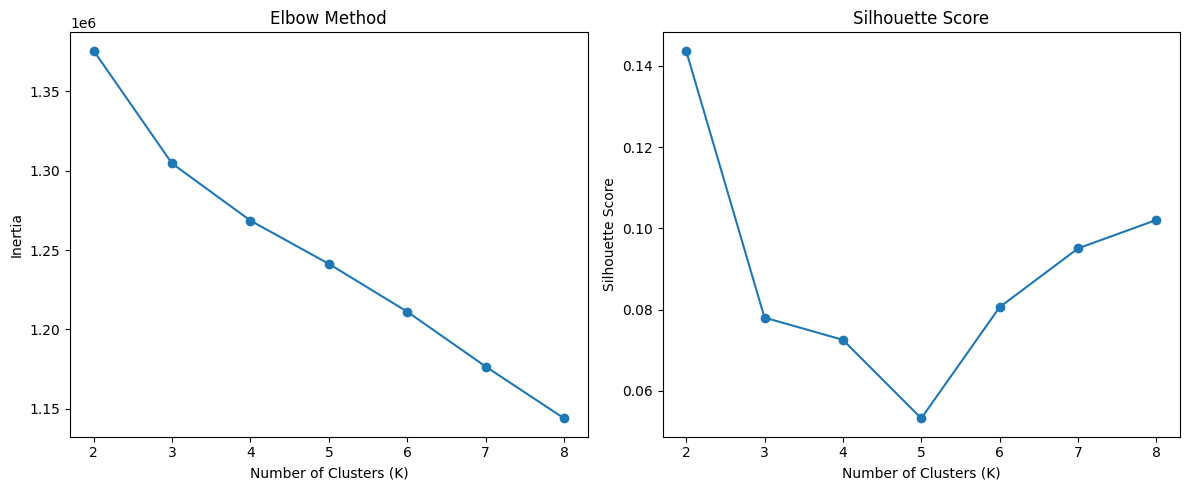

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(list(k_range), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(list(k_range), sil_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [9]:
kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=RANDOM_STATE
)

km_labels = kmeans.fit_predict(X)

sil = silhouette_score(
    X_sil_sample,
    km_labels[sil_sample_idx]
)

print("K-Means")
print("Number of clusters:", best_k)
print("Silhouette Score:", round(sil, 3))

print(
    "Cluster Sizes:",
    pd.Series(km_labels).value_counts().sort_index().to_dict()
)

K-Means
Number of clusters: 2
Silhouette Score: 0.144
Cluster Sizes: {0: 26429, 1: 23571}


In [10]:
profiled = feature_df.copy()

profiled["KMeansCluster"] = km_labels
profiled["PlacementStatus"] = df["PlacementStatus"].values

summary = profiled.groupby("KMeansCluster").agg(
    n_students=("PlacementStatus", "size"),
    placement_rate=("PlacementStatus", "mean"),
    avg_CGPA=("CGPA", "mean"),
    avg_AttendancePercent=("AttendancePercent", "mean"),
    avg_AptitudeTestScore=("AptitudeTestScore", "mean"),
    avg_SoftSkillsRating=("SoftSkillsRating", "mean"),
    avg_CodingTestScore=("CodingTestScore", "mean"),
    avg_MockInterviewScore=("MockInterviewScore", "mean"),
    avg_Internships=("Internships", "mean"),
    avg_Projects=("Projects", "mean")
).round(3)

print("Cluster Profiles:")
display(summary)

Cluster Profiles:


,n_students,placement_rate,avg_CGPA,avg_AttendancePercent,avg_AptitudeTestScore,avg_SoftSkillsRating,avg_CodingTestScore,avg_MockInterviewScore,avg_Internships,avg_Projects
KMeansCluster,,,,,,,,,,
0,26429,0.202,6.558,67.338,54.559,5.444,47.260,54.743,0.621,1.556
1,23571,0.781,8.131,83.340,76.411,7.658,74.035,76.239,1.978,3.628


In [11]:
sub_size = min(5000, len(X))

sub_idx = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X),
    sub_size,
    replace=False
)

X_sub = X[sub_idx]

hc = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hc_labels = hc.fit_predict(X_sub)

sil_hc = silhouette_score(
    X_sub,
    hc_labels
)

print("Hierarchical Clustering")
print("Silhouette Score:", round(sil_hc, 3))

Hierarchical Clustering
Silhouette Score: 0.114


In [12]:
db = DBSCAN(
    eps=4.0,
    min_samples=15
)

db_labels = db.fit_predict(X_sub)

n_db_clusters = len(
    set(db_labels)
) - (1 if -1 in db_labels else 0)

n_noise = np.sum(db_labels == -1)

print("DBSCAN")
print("Number of clusters:", n_db_clusters)
print("Noise points:", n_noise)

if n_db_clusters >= 2:

    mask = db_labels != -1

    db_sil = silhouette_score(
        X_sub[mask],
        db_labels[mask]
    )

    print(
        "Silhouette Score:",
        round(db_sil, 3)
    )

DBSCAN
Number of clusters: 6
Noise points: 2083
Silhouette Score: -0.064


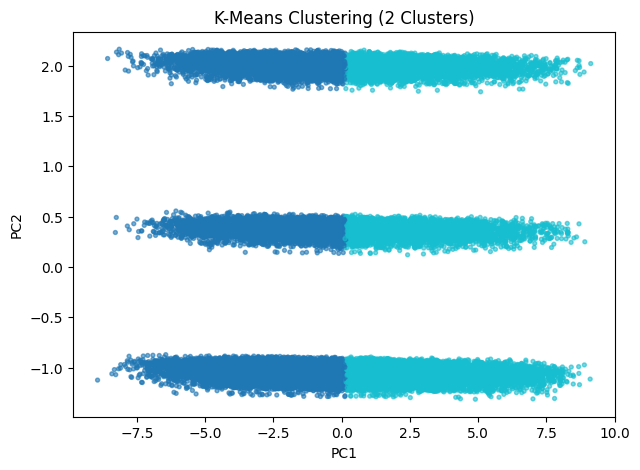

In [13]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=km_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.title(
    f"K-Means Clustering ({best_k} Clusters)"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

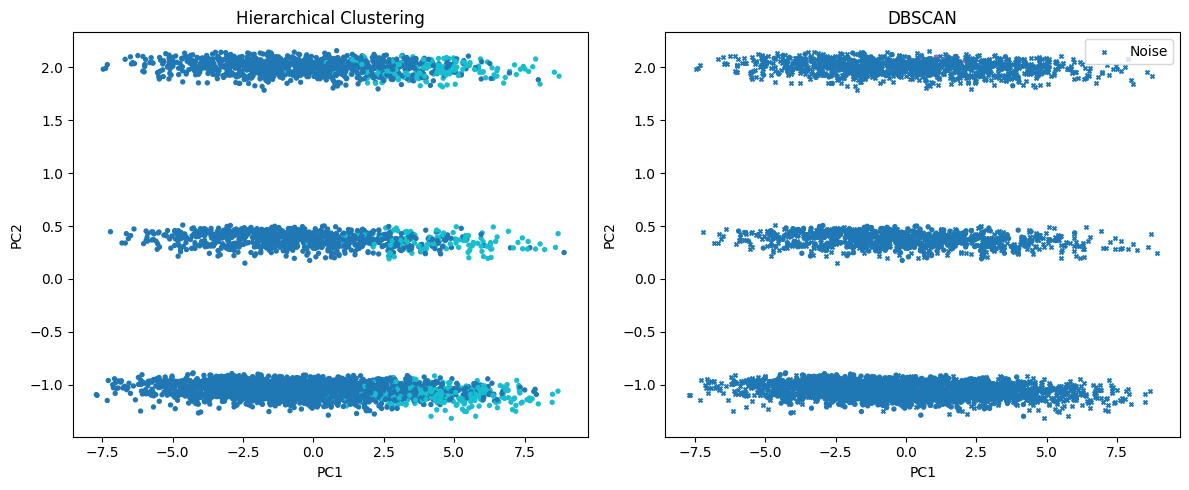

In [14]:
coords_sub = X_pca[sub_idx]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.scatter(
    coords_sub[:, 0],
    coords_sub[:, 1],
    c=hc_labels,
    cmap="tab10",
    s=8
)

plt.title("Hierarchical Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")


plt.subplot(1, 2, 2)

noise_mask = db_labels == -1

plt.scatter(
    coords_sub[~noise_mask, 0],
    coords_sub[~noise_mask, 1],
    c=db_labels[~noise_mask],
    cmap="tab10",
    s=8
)

plt.scatter(
    coords_sub[noise_mask, 0],
    coords_sub[noise_mask, 1],
    s=8,
    marker="x",
    label="Noise"
)

plt.title("DBSCAN")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.tight_layout()
plt.show()

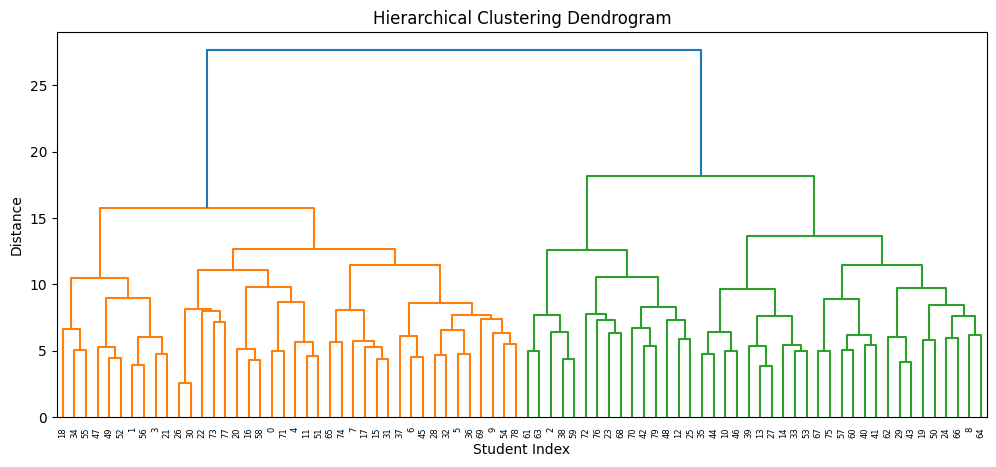

In [15]:
dendro_size = min(80, len(X_sub))

dendro_idx = np.random.choice(
    len(X_sub),
    size=dendro_size,
    replace=False
)

Z = linkage(
    X_sub[dendro_idx],
    method="ward"
)

plt.figure(figsize=(12, 5))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Student Index")
plt.ylabel("Distance")

plt.show()

In [16]:
df_out = df.copy()

df_out["KMeansCluster"] = km_labels

df_out.to_csv(
    "placement_predict_with_clusters.csv",
    index=False
)

summary.to_csv(
    "cluster_profiles.csv"
)

print("Files created successfully!")
print("1. placement_predict_with_clusters.csv")
print("2. cluster_profiles.csv")

Files created successfully!
1. placement_predict_with_clusters.csv
2. cluster_profiles.csv
